# ST1131 Quick Use Guide

This notebook is meant to be your **fast exam shortcut notebook**.

## 1. Choose the right function quickly

| What the question asks | Function / tool to use |
|---|---|
| Inspect dataset / columns / dimensions | `inspect_data(...)` |
| Frequency / proportion / percentage of a categorical variable | `frequency_table(...)` |
| One categorical variable | `plot_bar(...)` |
| One quantitative variable | `plot_histogram(...)` |
| One categorical + one quantitative | `plot_box(...)` |
| Two quantitative variables | `plot_scatter(...)` + `calculate_correlation(...)` |
| Two categorical variables | `contingency_table(...)` / `plot_contingency(...)` |
| Find suspected outliers | `find_outliers(...)` |
| Grouped summaries | `group_summary(...)` |
| Pivot-table style summary | `pivot_summary(...)` |
| Relative risk | `calculate_rr(...)` |
| Check association within levels of another variable | `stratified_tables(...)` |

---

## 2. Graph-choice reminder

Before plotting, identify the **variable types**.

| Variables | Main graph |
|---|---|
| 1 categorical | Bar plot |
| 1 quantitative | Histogram |
| 2 categorical | Contingency table + grouped / stacked bar plot |
| 1 categorical + 1 quantitative | Side-by-side boxplots |
| 2 quantitative | Scatter plot + correlation |

### Typical axis rule
- **Explanatory variable** → x-axis
- **Response variable** → y-axis

---

## 3. Interpretation reminders

### Histogram
Look for:
- overall shape
- gaps
- suspected outliers
- unimodal / bimodal / multimodal
- symmetric / left-skewed / right-skewed

### Bar plot
Mention:
- modal category
- proportion / percentage of modal category
- categories with high / low frequencies
- trend if categories are ordinal

### Boxplot
Compare:
- median
- IQR / spread
- outliers
- skewness
- which group tends to be higher

### Scatter plot
Check:
- association?
- positive / negative?
- approximately linear?
- strength?
- outliers?
- stable variability or fan shape?

### Correlation
Remember:
- between `-1` and `1`
- sign = direction
- magnitude = strength of **linear** association
- small `r` does not necessarily mean no relationship


# Descriptive Statistics Shortcut

Use this when the question asks you to **summarise one quantitative variable**.

This helper is **new**. None of your existing functions below have been changed.


In [ ]:
def descriptive_stats(data, column):
    """
    Return the main descriptive statistics for one quantitative column.

    Use when you want:
    count, mean, median, variance, standard deviation,
    min, Q1, Q3, IQR, max, and range.

    Example:
        descriptive_stats(df, "score")
    """
    s = data[column].dropna()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)

    return pd.Series({
        "count": s.count(),
        "mean": s.mean(),
        "median": s.median(),
        "variance": s.var(),
        "std": s.std(),
        "min": s.min(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,
        "max": s.max(),
        "range": s.max() - s.min()
    })


## How to use `descriptive_stats`

```python
descriptive_stats(df, "score")
```

Use the output like this:

- **mean / SD** → especially useful for roughly symmetric data
- **median / IQR** → especially useful for skewed data or data with outliers
- **range** → max − min
- **IQR** → Q3 − Q1

### Descriptive vs inferential
This function gives a **descriptive summary of the sample**.

If you use a sample statistic such as the sample mean to estimate a population parameter, that becomes **inferential statistics**.


# Fast Example Calls

These examples are here so you do not have to scroll around trying to remember argument order.

> Replace the dataset and column names with the ones in the exam.


In [ ]:
# inspect_data
inspect_data(df)

# frequency_table
frequency_table(df, "gender")

# plot_bar
plot_bar(df, "gender")

# plot_histogram
plot_histogram(df, "score")

# plot_box
plot_box(df, "score", "gender")

# contingency_table
contingency_table(df, "gender", "smoker")

# plot_contingency
plot_contingency(df, "gender", "smoker")

# plot_scatter
plot_scatter(df, "height", "weight")

# find_outliers
find_outliers(df, "score")

# calculate_correlation
calculate_correlation(df, "height", "weight")

# calculate_rr
calculate_rr(df, "exposure", "outcome")

# group_summary
group_summary(df, "gender", "score")

# stratified_tables
stratified_tables(df, "exposure", "outcome", "confounder")

# New helper added in this version
descriptive_stats(df, "score")

# Tiny Syntax Reminders

These are common pandas / DataCamp traps.

### One vs multiple columns
```python
df["height"]          # Series
df[["height"]]        # DataFrame
```

### `iloc` vs `loc`
```python
df.iloc[0]            # integer position
df.loc[0]             # label
```

### Filtering
```python
df[df["score"] > 80]

df[(df["score"] > 80) & (df["gender"] == "F")]

df[(df["score"] > 80) | (df["gender"] == "F")]
```

Use:
- `&` for AND
- `|` for OR
- `~` for NOT

### Proportions
```python
df["gender"].value_counts(normalize=True)
```

### Percentages
```python
df["gender"].value_counts(normalize=True) * 100
```

### Sort descending
```python
df.sort_values("score", ascending=False)
```

### Sample standard deviation
```python
df["score"].std()
```

For NumPy:
```python
np.std(x, ddof=1)
```


# ST1131 Function Shortcuts

Copy the import cell and the function cells into an exam notebook, then use the short calls at the end. Every function accepts a DataFrame instead of relying on a global `df`.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 0. Core Data Setup — pandas vs NumPy

Use this section when the question starts with:
- "load this file"
- "create a dataframe/array"
- "clean the data"
- "select/filter rows"
- "make a new column"
- "combine datasets"

## When should I use pandas vs NumPy?

| Need | Prefer |
|---|---|
| Table with named columns | **pandas** |
| CSV / Excel dataset | **pandas** |
| Filtering rows by column conditions | **pandas** |
| Grouping / pivot tables | **pandas** |
| Missing values in tabular data | **pandas** |
| Pure numerical arrays / matrices | **NumPy** |
| Fast element-wise numerical operations | **NumPy** |
| Generate ranges / random samples | **NumPy** |
| Reshape numerical arrays | **NumPy** |

For ST1131-style datasets, **pandas will usually be the main tool**, with NumPy used for numerical array operations.


# PANDAS — Loading, Creating, Inspecting, Cleaning, Manipulating

## P1. Load data from files

### CSV — most common

**Use case:** the exam gives you a `.csv` dataset.


In [ ]:
# Load a CSV file into a DataFrame
df = pd.read_csv("data.csv")

# Immediately inspect it
df.head()
df.shape
df.columns
df.dtypes


### CSV with useful options

**Use cases:**
- no header row
- tab-separated file
- selected columns only
- custom missing-value markers


In [ ]:
# No header row
df = pd.read_csv("data.csv", header=None)

# Tab-separated file
df = pd.read_csv("data.txt", sep="\t")

# Read selected columns only
df = pd.read_csv(
    "data.csv",
    usecols=["age", "score", "gender"]
)

# Treat extra strings as missing values
df = pd.read_csv(
    "data.csv",
    na_values=["NA", "missing", "?"]
)


### Excel

**Use case:** dataset is `.xlsx` or `.xls`.


In [ ]:
df = pd.read_excel("data.xlsx")

# Specific worksheet
df = pd.read_excel("data.xlsx", sheet_name="Sheet1")


### Save/export data

**Use case:** save your cleaned or transformed DataFrame.


In [ ]:
# Save without the pandas index column
df.to_csv("cleaned_data.csv", index=False)

# Save to Excel
df.to_excel("cleaned_data.xlsx", index=False)


## P2. Create a DataFrame or Series manually

### DataFrame from a dictionary

**Use case:** question gives small values directly rather than a file.


In [ ]:
df = pd.DataFrame({
    "name": ["A", "B", "C"],
    "score": [80, 75, 91],
    "group": ["X", "Y", "X"]
})

df


### Series

**Use case:** one labelled column/vector of data.


In [ ]:
scores = pd.Series([80, 75, 91, 68])

scores


## P3. Inspect a dataset

**Use case:** first thing to run when you receive an unfamiliar dataset.


In [ ]:
df.head()          # first 5 rows
df.tail()          # last 5 rows
df.shape           # (number of rows, number of columns)
df.columns         # column names
df.index           # row index
df.dtypes          # datatype of each column
df.info()          # structure + missing-value overview
df.describe()      # numerical summaries


## P4. Select columns and rows

### One column

**Use case:** work with one variable.


In [ ]:
df["score"]


### Multiple columns

**Use case:** keep a subset of variables.


In [ ]:
df[["score", "group"]]


### `iloc` = integer positions

**Use case:** select by row/column position.


In [ ]:
df.iloc[0]          # first row
df.iloc[0:3]        # first 3 rows
df.iloc[:, 0]       # first column
df.iloc[0:3, 0:2]   # rows 0-2, columns 0-1


### `loc` = labels / conditions

**Use case:** select by column names or Boolean condition.


In [ ]:
df.loc[:, ["score", "group"]]

df.loc[df["score"] > 80, ["score", "group"]]


## P5. Filter rows

### One condition


In [ ]:
df[df["score"] > 80]


### AND / OR / NOT

**Use case:** combine conditions.

Remember:
- `&` = AND
- `|` = OR
- `~` = NOT
- put each condition inside parentheses


In [ ]:
# AND
df[(df["score"] > 80) & (df["group"] == "X")]

# OR
df[(df["score"] > 80) | (df["group"] == "X")]

# NOT
df[~(df["group"] == "X")]


### `.isin()`

**Use case:** keep rows where a value belongs to a list/set of categories.


In [ ]:
df[df["group"].isin(["X", "Z"])]


### `.between()`

**Use case:** keep values within an interval.


In [ ]:
df[df["score"].between(70, 90)]


## P6. Sort data

**Use case:** find highest/lowest observations or arrange rows.


In [ ]:
# Ascending
df.sort_values("score")

# Descending
df.sort_values("score", ascending=False)

# Multiple columns
df.sort_values(
    ["group", "score"],
    ascending=[True, False]
)


## P7. Add or transform columns

### New calculated column

**Use case:** derive a new variable such as BMI, total, rate, difference, etc.


In [ ]:
df["score_percent"] = df["score"] / 100

# Example with two columns
# df["bmi"] = df["weight"] / (df["height_m"] ** 2)


### Conditional column

**Use case:** convert a quantitative variable into categories.


In [ ]:
df["result"] = np.where(
    df["score"] >= 50,
    "Pass",
    "Fail"
)


## P8. Rename columns

**Use case:** make awkward column names easier to use.


In [ ]:
df = df.rename(
    columns={
        "old_name": "new_name",
        "Score (%)": "score"
    }
)


## P9. Drop rows or columns

**Use case:** remove unwanted variables or observations.


In [ ]:
# Drop a column
df = df.drop(columns=["unwanted_column"])

# Drop several columns
df = df.drop(columns=["col1", "col2"])

# Drop a row by index
df = df.drop(index=0)


## P10. Change datatype with `.astype()`

**Use case:** a number was read as a string, or you want categorical/string conversion.


In [ ]:
# Convert to integer
df["age"] = df["age"].astype(int)

# Convert to float
df["score"] = df["score"].astype(float)

# Convert to string
df["id"] = df["id"].astype(str)

# Convert to category
df["group"] = df["group"].astype("category")


## P11. Missing values

### Detect missing values

**Use case:** check whether cleaning is needed.


In [ ]:
df.isna()          # True/False for each cell
df.isna().sum()    # number missing in each column


### Drop missing values

**Use case:** remove observations that cannot be analysed.


In [ ]:
# Drop rows with any missing value
clean_df = df.dropna()

# Drop only if a particular variable is missing
clean_df = df.dropna(subset=["score"])


### Fill missing values

**Use case:** replace missing values with a chosen value/statistic.


In [ ]:
# Fill missing score with mean
df["score"] = df["score"].fillna(
    df["score"].mean()
)

# Fill missing category
df["group"] = df["group"].fillna("Unknown")


## P12. Duplicates

**Use case:** detect or remove repeated observations.


In [ ]:
# Number of duplicated rows
df.duplicated().sum()

# Show duplicated rows
df[df.duplicated()]

# Remove duplicates
df = df.drop_duplicates()


## P13. Unique values

**Use case:** find all categories and how many distinct values exist.


In [ ]:
df["group"].unique()     # actual unique values
df["group"].nunique()    # number of unique values


## P14. Frequency / proportion / percentage

**Use case:** summarise one categorical variable.


In [ ]:
# Frequency
df["group"].value_counts()

# Proportion
df["group"].value_counts(normalize=True)

# Percentage
df["group"].value_counts(normalize=True) * 100


## P15. Grouping

### `groupby()`

**Use case:** compare a numerical variable across categories.


In [ ]:
# Mean score in each group
df.groupby("group")["score"].mean()

# Several statistics
df.groupby("group")["score"].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max"
])


## P16. `agg()`

**Use case:** calculate several summaries at once.


In [ ]:
df["score"].agg([
    "count",
    "mean",
    "median",
    "std",
    "var",
    "min",
    "max"
])


## P17. Pivot tables

**Use case:** spreadsheet-style summary across two grouping variables.


In [ ]:
pd.pivot_table(
    df,
    values="score",
    index="group",
    columns="gender",
    aggfunc="mean"
)


## P18. Crosstab / contingency table

**Use case:** association between **two categorical variables**.


In [ ]:
# Counts
pd.crosstab(
    df["gender"],
    df["smoker"]
)

# Row-wise proportions
pd.crosstab(
    df["gender"],
    df["smoker"],
    normalize="index"
)

# Row-wise percentages
pd.crosstab(
    df["gender"],
    df["smoker"],
    normalize="index"
) * 100


## P19. Cumulative functions

**Use cases:**
- running total
- highest value seen so far
- lowest value seen so far
- cumulative growth/product


In [ ]:
df["sales"].cumsum()    # cumulative sum
df["sales"].cummax()    # cumulative maximum
df["sales"].cummin()    # cumulative minimum
df["growth"].cumprod()  # cumulative product


## P20. Set / reset index

**Use case:** use a column as row labels, or return to the default numeric index.


In [ ]:
# Make id the index
df2 = df.set_index("id")

# Return index to a normal column
df2 = df2.reset_index()

# Throw away old index completely
df2 = df2.reset_index(drop=True)


## P21. Combine datasets

### `pd.concat()`

**Use case:** stack datasets with the same/similar columns.


In [ ]:
# Stack rows
combined = pd.concat(
    [df1, df2],
    ignore_index=True
)

# Combine side-by-side
combined = pd.concat(
    [df1, df2],
    axis=1
)


### `pd.merge()`

**Use case:** join two tables using a common key such as student ID.


In [ ]:
merged = pd.merge(
    students,
    results,
    on="student_id",
    how="inner"
)

# Common options:
# how="inner"  -> keep matches in both
# how="left"   -> keep all rows from left table
# how="right"  -> keep all rows from right table
# how="outer"  -> keep all rows from both


## P22. Basic string operations

**Use case:** clean or filter text/categorical columns.


In [ ]:
# Lowercase / uppercase
df["name"].str.lower()
df["name"].str.upper()

# Remove extra spaces
df["name"].str.strip()

# Check whether text contains a pattern
df[df["name"].str.contains("ann", case=False, na=False)]


## P23. Quick pandas exam workflow

```python
# 1. Load
df = pd.read_csv("data.csv")

# 2. Inspect
df.head()
df.shape
df.columns
df.dtypes
df.isna().sum()

# 3. Select / filter
df[df["score"] > 80]

# 4. Summarise
df["score"].describe()
df["group"].value_counts()

# 5. Group if needed
df.groupby("group")["score"].mean()

# 6. Plot using the functions later in this notebook
```


# NUMPY — Arrays and Numerical Operations

Use NumPy when the task is mainly about **numbers rather than labelled table columns**.


## N1. Create arrays

### `np.array()`

**Use case:** manually create a numerical array.


In [ ]:
x = np.array([10, 20, 30, 40])

x


### 2D array / matrix

**Use case:** numerical grid or matrix.


In [ ]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

A


## N2. Load numerical data from files

### `np.loadtxt()`

**Use case:** clean file containing only numerical values.


In [ ]:
data = np.loadtxt(
    "data.csv",
    delimiter=","
)


### `np.genfromtxt()`

**Use case:** numerical file with a header or missing values.


In [ ]:
data = np.genfromtxt(
    "data.csv",
    delimiter=",",
    skip_header=1
)


## N3. Save a NumPy array

**Use case:** export numerical output.


In [ ]:
np.savetxt(
    "output.csv",
    data,
    delimiter=","
)


## N4. Create sequences

### `np.arange()`

**Use case:** regularly spaced values with a chosen step.

Like Python `range()`, the stop value is normally excluded.


In [ ]:
np.arange(0, 10, 2)
# -> 0, 2, 4, 6, 8


### `np.linspace()`

**Use case:** create an exact number of equally spaced points between two endpoints.


In [ ]:
np.linspace(0, 1, 5)
# 5 evenly spaced values from 0 to 1


## N5. Inspect array shape / dimensions

**Use case:** check dimensions before indexing or reshaping.


In [ ]:
x.shape
x.ndim
x.size
x.dtype


## N6. Indexing and slicing

### 1D array


In [ ]:
x = np.array([10, 20, 30, 40, 50])

x[0]       # first value
x[-1]      # last value
x[1:4]     # positions 1,2,3
x[:3]      # first 3 values
x[::2]     # every second value


### 2D array

**Use case:** select rows/columns from a matrix.


In [ ]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

A[0, 1]     # row 0, column 1
A[0, :]     # first row
A[:, 1]     # second column
A[0:2, 1:3] # submatrix


## N7. Boolean filtering

**Use case:** keep numerical values satisfying a condition.


In [ ]:
x = np.array([12, 18, 25, 31, 40])

x[x > 20]

x[(x >= 18) & (x <= 31)]


## N8. Basic numerical summaries

**Use case:** descriptive statistics directly on an array.


In [ ]:
np.sum(x)
np.mean(x)
np.median(x)
np.min(x)
np.max(x)

# Sample SD / variance for ST1131
np.std(x, ddof=1)
np.var(x, ddof=1)

np.quantile(x, 0.25)
np.quantile(x, 0.50)
np.quantile(x, 0.75)


## N9. Element-wise arithmetic

**Use case:** transform every observation at once.


In [ ]:
x = np.array([1, 2, 3, 4])

x + 10
x * 2
x ** 2
np.sqrt(x)
np.log(x)


### Array with array operations

NumPy applies arithmetic element-by-element when shapes are compatible.


In [ ]:
a = np.array([1, 2, 3])
b = np.array([10, 20, 30])

a + b
a * b


## N10. Reshape

**Use case:** reorganise the same values into a different array shape.


In [ ]:
x = np.arange(1, 7)

x.reshape(2, 3)


## N11. Flatten

**Use case:** turn a multi-dimensional array into one dimension.


In [ ]:
A = np.array([
    [1, 2],
    [3, 4]
])

A.flatten()


## N12. Combine arrays

**Use case:** append or stack numerical arrays.


In [ ]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

np.concatenate([a, b])

# For 2D arrays:
# np.vstack([A, B])   -> stack rows
# np.hstack([A, B])   -> stack columns


## N13. Random numbers / simulation

**Use case:** probability simulation or random sampling.


In [ ]:
rng = np.random.default_rng(1)

# Random integers from 1 to 6 inclusive
rolls = rng.integers(1, 7, size=1000)

# Random sample from categories
tosses = rng.choice(
    ["H", "T"],
    size=1000,
    replace=True
)

# Estimated probability of Heads
np.mean(tosses == "H")


## N14. Missing values in numerical arrays

**Use case:** data contains `NaN`.


In [ ]:
x = np.array([1.0, 2.0, np.nan, 4.0])

np.isnan(x)

# Ignore NaN while calculating
np.nanmean(x)
np.nanmedian(x)
np.nanstd(x, ddof=1)


# pandas vs NumPy — Same Task, Different Style

## Mean

```python
# pandas
df["score"].mean()

# NumPy
np.mean(x)
```

## Filter values

```python
# pandas
df[df["score"] > 80]

# NumPy
x[x > 80]
```

## Sample standard deviation

```python
# pandas
df["score"].std()

# NumPy
np.std(x, ddof=1)
```

## Main idea

- If your data has **named columns and rows**, use **pandas**.
- If you have a **plain numerical array**, use **NumPy**.


# Ultra-Quick Data Setup Lookup

| Need | Code |
|---|---|
| Load CSV | `pd.read_csv("file.csv")` |
| Load Excel | `pd.read_excel("file.xlsx")` |
| Save CSV | `df.to_csv("file.csv", index=False)` |
| Create DataFrame | `pd.DataFrame({...})` |
| Create NumPy array | `np.array([...])` |
| Load numeric CSV | `np.loadtxt("file.csv", delimiter=",")` |
| Inspect first rows | `df.head()` |
| Dimensions | `df.shape` |
| Datatypes | `df.dtypes` |
| Select one column | `df["x"]` |
| Select columns | `df[["x","y"]]` |
| Filter rows | `df[df["x"] > 5]` |
| Values in list | `df[df["x"].isin([...])]` |
| Between values | `df[df["x"].between(a,b)]` |
| Sort | `df.sort_values("x")` |
| Add column | `df["new"] = ...` |
| Rename | `df.rename(columns={...})` |
| Drop column | `df.drop(columns=[...])` |
| Change type | `df["x"].astype(int)` |
| Count missing | `df.isna().sum()` |
| Drop missing | `df.dropna()` |
| Fill missing | `df["x"].fillna(...)` |
| Remove duplicates | `df.drop_duplicates()` |
| Unique values | `df["x"].unique()` |
| Group | `df.groupby("g")["x"].mean()` |
| Pivot | `pd.pivot_table(...)` |
| Crosstab | `pd.crosstab(...)` |
| Merge | `pd.merge(...)` |
| Concatenate | `pd.concat(...)` |
| Cumulative sum | `df["x"].cumsum()` |
| NumPy range | `np.arange(...)` |
| Evenly spaced values | `np.linspace(...)` |
| NumPy reshape | `x.reshape(...)` |


## Runnable example data

The functions work with other datasets. Replace this cell with `pd.read_csv(...)` and your own column names.

In [4]:
df = pd.DataFrame({
    "gender": ["Female", "Male", "Female", "Male", "Female", "Male", "Female", "Male"],
    "smoker": ["No", "Yes", "No", "Yes", "No", "No", "Yes", "Yes"],
    "disease": ["No", "Yes", "No", "Yes", "No", "No", "Yes", "No"],
    "age": [19, 21, 22, 24, 26, 29, 31, 70],
    "score": [68, 75, 72, 81, 77, 84, 90, 99],
    "hours": [2, 4, 3, 6, 5, 7, 8, 10],
})

CAT = "gender"
GROUP = "smoker"
OUTCOME = "disease"
NUM = "score"
X = "hours"
Y = "score"

## 1. Inspection and frequency tables

- `inspect_data(data)` prints the main structural checks and returns them in a dictionary.
- `frequency_table(data, column)` returns counts, proportions and percentages.

In [6]:
def inspect_data(data, preview_rows=5, show_describe=True):
    """Print key checks, display previews, and return inspection results."""
    summary = {
        "rows": len(data),
        "columns": data.shape[1],
        "shape": data.shape,
        "size": data.size,
        "column_names": data.columns.tolist(),
        "missing_by_column": data.isna().sum(),
        "duplicate_rows": data.duplicated().sum(),
    }

    print("Rows:", summary["rows"])
    print("Columns:", summary["columns"])
    print("Shape:", summary["shape"])
    print("Size:", summary["size"])
    print("Column names:", summary["column_names"])
    print("Duplicate rows:", summary["duplicate_rows"])
    print("Missing values:")
    display(summary["missing_by_column"])
    data.info()
    display(data.head(preview_rows))

    if show_describe:
        display(data.describe(include="all"))

    return summary


def frequency_table(data, column, sort=False, dropna=False):
    """Return category counts, proportions, and percentages."""
    counts = data[column].value_counts(sort=sort, dropna=dropna)
    proportions = data[column].value_counts(normalize=True, sort=sort, dropna=dropna)

    return pd.DataFrame({
        "frequency": counts,
        "proportion": proportions,
        "percentage": proportions * 100,
    })

print(inspect_data(df))
print(frequency_table(df, 'gender'))

Rows: 8
Columns: 6
Shape: (8, 6)
Size: 48
Column names: ['gender', 'smoker', 'disease', 'age', 'score', 'hours']
Duplicate rows: 0
Missing values:


gender     0
smoker     0
disease    0
age        0
score      0
hours      0
dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   gender   8 non-null      str  
 1   smoker   8 non-null      str  
 2   disease  8 non-null      str  
 3   age      8 non-null      int64
 4   score    8 non-null      int64
 5   hours    8 non-null      int64
dtypes: int64(3), str(3)
memory usage: 516.0 bytes


,gender,smoker,disease,age,score,hours
0,Female,No,No,19,68,2
1,Male,Yes,Yes,21,75,4
2,Female,No,No,22,72,3
3,Male,Yes,Yes,24,81,6
4,Female,No,No,26,77,5


,gender,smoker,disease,age,score,hours
count,8,8,8,8.000000,8.000000,8.00000
unique,2,2,2,NaN,NaN,NaN
top,Female,No,No,NaN,NaN,NaN
freq,4,4,5,NaN,NaN,NaN
mean,NaN,NaN,NaN,30.250000,80.750000,5.62500
std,NaN,NaN,NaN,16.559417,10.110108,2.66927
min,NaN,NaN,NaN,19.000000,68.000000,2.00000
25%,NaN,NaN,NaN,21.750000,74.250000,3.75000
50%,NaN,NaN,NaN,25.000000,79.000000,5.50000
75%,NaN,NaN,NaN,29.500000,85.500000,7.25000


{'rows': 8, 'columns': 6, 'shape': (8, 6), 'size': 48, 'column_names': ['gender', 'smoker', 'disease', 'age', 'score', 'hours'], 'missing_by_column': gender     0
smoker     0
disease    0
age        0
score      0
hours      0
dtype: int64, 'duplicate_rows': np.int64(0)}
        frequency  proportion  percentage
gender                                   
Female          4         0.5        50.0
Male            4         0.5        50.0


## 2. Visualisation functions

Every plotting function labels the graph, calls `plt.show()`, and returns the axis so it can still be customised.

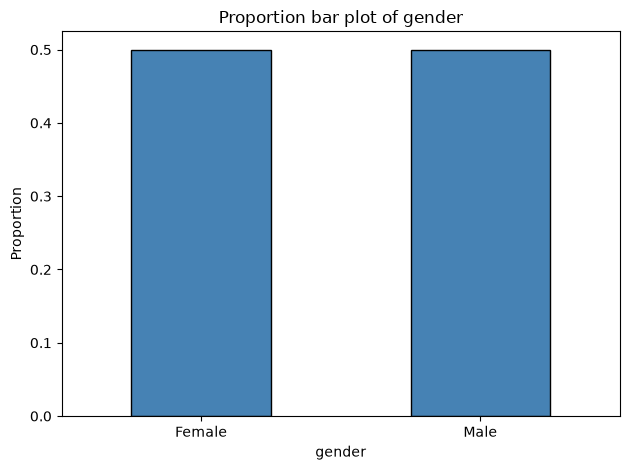

Axes(0.104085,0.122814;0.872478x0.801491)


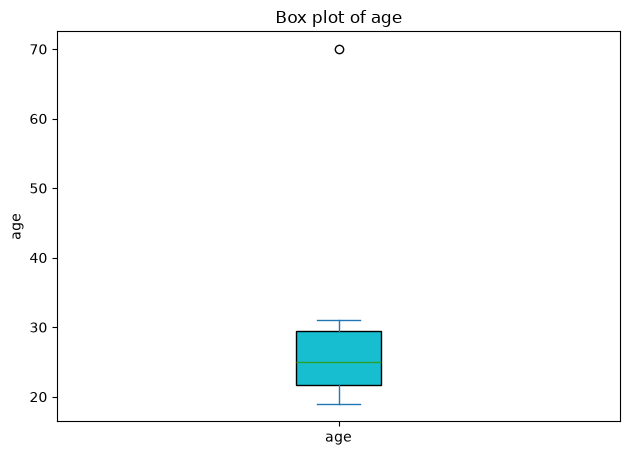

Axes(0.0971354,0.0804398;0.879427x0.812616)


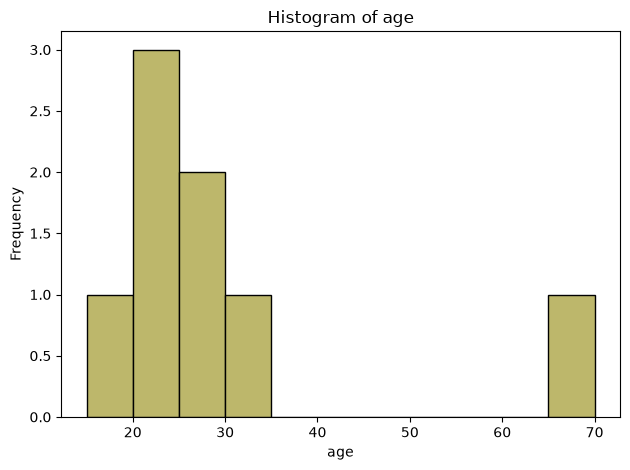

Axes(0.103385,0.120949;0.873177x0.803356)


In [ ]:
# plot single bar chart
def plot_bar(data, column, normalize=False, dropna=False, sort=False, color="steelblue", rotation=0):
    """Plot category frequencies or proportions."""
    values = data[column].value_counts(normalize=normalize, dropna=dropna, sort=sort)
    ylabel = "Proportion" if normalize else "Frequency"
    title_prefix = "Proportion bar plot" if normalize else "Bar plot"

    ax = values.plot(kind="bar", color=color, edgecolor="black")
    ax.set(xlabel=column, ylabel=ylabel, title=f"{title_prefix} of {column}")
    ax.tick_params(axis="x", rotation=rotation)
    plt.tight_layout()
    plt.show()
    return ax

# plot hist 
def plot_histogram(data, column, bins=10, density=False, color="darkkhaki"):
    """Plot a histogram for one quantitative column."""
    ax = data[column].dropna().plot(
        kind="hist", bins=bins, density=density, color=color, edgecolor="black"
    )
    ylabel = "Density" if density else "Frequency"
    ax.set(xlabel=column, ylabel=ylabel, title=f"Histogram of {column}")
    plt.tight_layout()
    plt.show()
    return ax

# plot box-plot
def plot_box(data, value, group=None, color="tab:cyan"):
    """Plot one boxplot or side-by-side boxplots when group is supplied."""
    if group is None:
        ax = data[[value]].plot(
            kind="box", patch_artist=True, boxprops={"facecolor": color}
        )
        ax.set(title=f"Box plot of {value}", ylabel=value)
    else:
        ax = data.boxplot(column=value, by=group, grid=False, patch_artist=True)
        ax.set(title=f"{value} by {group}", xlabel=group, ylabel=value)

    plt.suptitle("")
    plt.tight_layout()
    plt.show()
    return ax

print(plot_bar(df, 'gender', normalize=True))
print(plot_box(df, 'age'))
print(plot_histogram(df, 'age', bins=np.arange(15, 71, 5), ))


disease,No,Yes
smoker,,
No,4,0
Yes,1,3


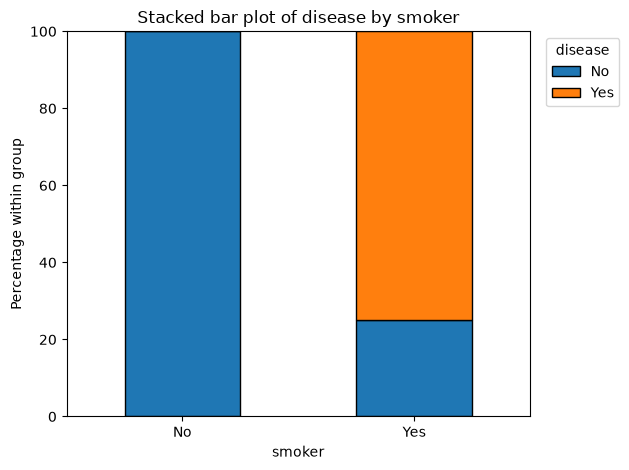

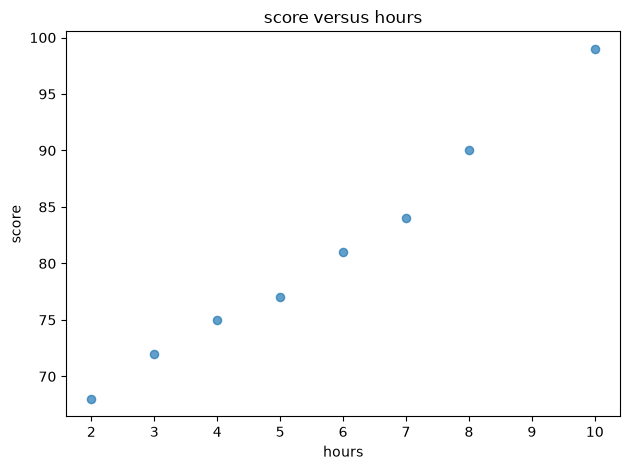

<Axes: title={'center': 'score versus hours'}, xlabel='hours', ylabel='score'>

In [17]:
def contingency_table(data, explanatory, response, normalize=None, dropna=False, decimals=1):
    """Return counts, or percentages when normalize is 'index', 'columns', or 'all'."""
    normalization = False if normalize is None else normalize
    table = pd.crosstab(
        data[explanatory], data[response], normalize=normalization, dropna=dropna
    )

    if normalize is not None:
        table = table * 100

    return table.round(decimals)


def plot_contingency(data, explanatory, response, stacked=False, colors=None, rotation=0):
    """Plot row percentages for two categorical variables."""
    percentages = contingency_table(data, explanatory, response, normalize="index")
    ax = percentages.plot(
        kind="bar", stacked=stacked, color=colors, edgecolor="black"
    )
    plot_type = "Stacked" if stacked else "Clustered"
    ax.set(
        xlabel=explanatory,
        ylabel="Percentage within group",
        title=f"{plot_type} bar plot of {response} by {explanatory}",
    )
    ax.legend(title=response, bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.tick_params(axis="x", rotation=rotation)
    plt.tight_layout()
    plt.show()
    return ax


def plot_scatter(data, x, y, group=None, alpha=0.7, size=35):
    """Plot two quantitative variables, optionally coloured by a category."""
    fig, ax = plt.subplots()

    if group is None:
        ax.scatter(data[x], data[y], alpha=alpha, s=size, color="tab:blue")
        title = f"{y} versus {x}"
    else:
        for label, subset in data.groupby(group, observed=False):
            ax.scatter(subset[x], subset[y], label=label, alpha=alpha, s=size)
        ax.legend(title=group)
        title = f"{y} versus {x}, grouped by {group}"

    ax.set(xlabel=x, ylabel=y, title=title)
    plt.tight_layout()
    plt.show()
    return ax

display(contingency_table(df, 'smoker', 'disease'))
plot_contingency(df, 'smoker', 'disease', stacked=True)
plot_scatter(df, 'hours', 'score')

## 3. IQR outlier functions

`find_outliers()` returns a dictionary containing the fences, Boolean mask and outlying rows. Supply `group=` to calculate separate fences within every group.

In [21]:
def _iqr_bounds(series, multiplier=1.5):
    """Return Q1, Q3, IQR and IQR fences for one Series."""
    clean = series.dropna()
    q1 = clean.quantile(0.25)
    q3 = clean.quantile(0.75)
    iqr = q3 - q1
    return q1, q3, iqr, q1 - multiplier * iqr, q3 + multiplier * iqr




def find_outliers(data, column, group=None, multiplier=1.5):
    """Return IQR fences, an outlier mask, and complete outlying rows."""
    if group is None:
        q1, q3, iqr, lower, upper = _iqr_bounds(data[column], multiplier)
        mask = data[column].notna() & ~data[column].between(lower, upper)
        return {
            "q1": q1, "q3": q3, "iqr": iqr,
            "lower_fence": lower, "upper_fence": upper,
            "mask": mask, "outliers": data.loc[mask].copy(),
        }

    grouped = data.groupby(group, observed=False)[column]
    q1 = grouped.transform(lambda values: values.quantile(0.25))
    q3 = grouped.transform(lambda values: values.quantile(0.75))
    iqr = q3 - q1
    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr
    mask = data[column].notna() & ((data[column] < lower) | (data[column] > upper))

    return {
        "q1": q1, "q3": q3, "iqr": iqr,
        "lower_fence": lower, "upper_fence": upper,
        "mask": mask, "outliers": data.loc[mask].copy(),
    }

result_outliers = find_outliers(df, 'age')
print(result_outliers['outliers'])


def remove_outliers(data, column, group=None, multiplier=1.5):
    """Return (cleaned_data, removed_rows) without changing the original DataFrame."""
    result = find_outliers(data, column, group=group, multiplier=multiplier)
    cleaned = data.loc[~result["mask"]].copy()
    return cleaned, result["outliers"]

clean_df, outliers = remove_outliers(df, 'age')

  gender smoker disease  age  score  hours
7   Male    Yes      No   70     99     10


## 4. Correlation and relative risk

Correlation uses complete `(x, y)` pairs. Relative risk returns both group risks and their ratio.

In [24]:
def calculate_correlation(data, x, y, decimals=4):
    """Return the Pearson correlation for complete x-y pairs."""
    paired = data[[x, y]].dropna()

    if len(paired) < 2:
        return np.nan

    return round(paired[x].corr(paired[y]), decimals)

print(calculate_correlation(df, 'hours', 'score'))


def calculate_rr(data, exposure, outcome, exposed_value, unexposed_value, event_value):
    """Return exposed risk, unexposed risk and relative risk."""
    exposed_outcomes = data.loc[data[exposure].eq(exposed_value), outcome]
    unexposed_outcomes = data.loc[data[exposure].eq(unexposed_value), outcome]

    if exposed_outcomes.empty or unexposed_outcomes.empty:
        raise ValueError("Both exposure groups must contain observations.")

    risk_exposed = exposed_outcomes.eq(event_value).mean()
    risk_unexposed = unexposed_outcomes.eq(event_value).mean()
    risk_ratio = np.inf if risk_unexposed == 0 else risk_exposed / risk_unexposed

    return pd.Series({
        "risk_exposed": risk_exposed,
        "risk_unexposed": risk_unexposed,
        "risk_difference": risk_exposed - risk_unexposed,
        "risk_ratio": risk_ratio,
    })

print(calculate_rr(df, 'gender', 'disease', 'Male', 'Female', 'Yes'))

0.9912
risk_exposed       0.50
risk_unexposed     0.25
risk_difference    0.25
risk_ratio         2.00
dtype: float64


## 5. Grouped summaries and pivot tables

In [ ]:
def group_summary(data, group, value):
    """Return common descriptive statistics for each group."""
    return data.groupby(group, observed=False)[value].agg(
        count="count",
        minimum="min",
        maximum="max",
        mean="mean",
        median="median",
        sample_std="std",
    )


def make_pivot(data, value, rows, columns, aggfunc="mean", fill_value=None, margins=False):
    """Return a pivot table for a quantitative value and two categorical variables."""
    return data.pivot_table(
        values=value,
        index=rows,
        columns=columns,
        aggfunc=aggfunc,
        fill_value=fill_value,
        margins=margins,
        observed=False,
    )

## 6. Slicing by a possible confounder

In [ ]:
def stratified_tables(data, confounder, explanatory, response, decimals=1, show=True):
    """Return row-percentage tables within every confounder level."""
    tables = {}

    for level, subset in data.groupby(confounder, observed=False):
        table = contingency_table(
            subset, explanatory, response, normalize="index", decimals=decimals
        )
        tables[level] = table

        if show:
            print(f"{confounder} = {level}")
            display(table)

    return tables


def stratified_rr(data, confounder, exposure, outcome, exposed_value, unexposed_value, event_value):
    """Return the relative risk calculated separately within every confounder level."""
    results = {}

    for level, subset in data.groupby(confounder, observed=False):
        results[level] = calculate_rr(
            subset, exposure, outcome, exposed_value, unexposed_value, event_value
        )["risk_ratio"]

    return pd.Series(results, name="risk_ratio")

## 7. Quick call reference

Run the required function cells first, then change only the DataFrame and column arguments below.

In [ ]:
inspection = inspect_data(df, show_describe=False)
display(frequency_table(df, CAT))

plot_bar(df, CAT)
plot_bar(df, CAT, normalize=True)
plot_histogram(df, NUM, bins=5)
plot_box(df, NUM)
plot_box(df, NUM, group=GROUP)

display(contingency_table(df, GROUP, OUTCOME))
display(contingency_table(df, GROUP, OUTCOME, normalize="index"))
plot_contingency(df, GROUP, OUTCOME, stacked=False)
plot_scatter(df, X, Y, group=GROUP)

outlier_result = find_outliers(df, NUM)
display(outlier_result["outliers"])
clean_df, removed_rows = remove_outliers(df, NUM)

correlation = calculate_correlation(df, X, Y)
print("Correlation:", correlation)

rr_result = calculate_rr(df, GROUP, OUTCOME, "Yes", "No", "Yes")
display(rr_result)

display(group_summary(df, GROUP, NUM))
display(make_pivot(df, NUM, rows=CAT, columns=GROUP, aggfunc=["mean", "median", "count"]))

stratified_tables(df, CAT, GROUP, OUTCOME)
display(stratified_rr(df, CAT, GROUP, OUTCOME, "Yes", "No", "Yes"))